In [3]:
import sys
sys.path.append('..')

from shipClass.Ship import Ship
from shipClass.SensedShip import SensedShip

import numpy.random as npr
npr.seed(11)  # for reproducibility

Simple system test to check relevant data calculation

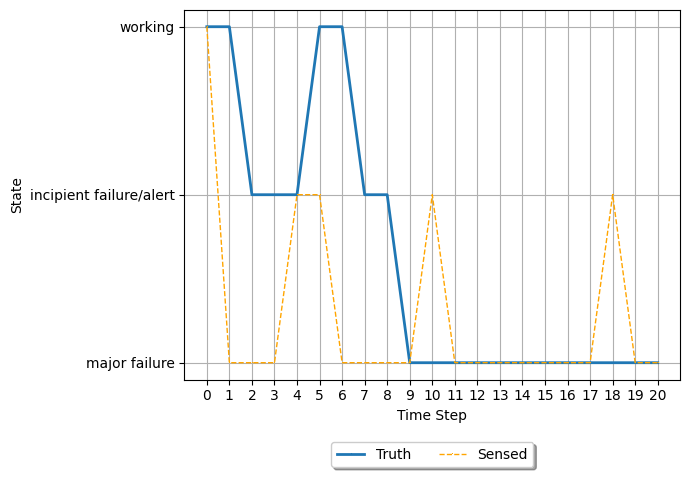

False Alarm Rate: 15.0
Unexpected Failure Rate: 16.666666666666664
Truth History: [2, np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Sensed History: [2, np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]


In [22]:
# initialize a repairable ship
simple_ship = Ship('SimpleShip_Repairable', 
                        'simple_test_ship_data.xlsx', 
                        repairable=True)

# initialize a sensed ship
sensors = [[(3,'bad') for comps in system.comps] for system in simple_ship.systems.values()]  # number of sensors per component, sensor quality
sensed_simple_ship = SensedShip(simple_ship, sensors)

# simulate and plot results
sensed_simple_ship.simulate(20)
sensed_simple_ship.plotHistory()

# check relevant data calculations
false_alarm_rate = sensed_simple_ship.getFalseAlarmRate()
unexpected_failure_rate = sensed_simple_ship.getUnexpectedFailureRate()
print(f'False Alarm Rate: {false_alarm_rate}')
print(f'Unexpected Failure Rate: {unexpected_failure_rate}')

# print histories
print('Truth History:', sensed_simple_ship.ship.history)
print('Sensed History:', sensed_simple_ship.sensedHistory)

In [4]:
# specify (sensor number and quality) for each simulation
# simulation_parameters =[ (7, 'bad'),         # 1 bad quality sensor per component
#                          (7, 'moderate'),   # 1 moderate quality sensor per component
#                          (7, 'good')]       # 1 good quality sensor per component
# specify (sensor number and quality) for each simulation
simulation_parameters =[(1, 'bad'),         # 1 bad quality sensor per component
                        (1, 'moderate'),   # 1 moderate quality sensor per component
                        (1, 'good'),       # 1 good quality sensor per component
                        (3, 'bad'),        # 3 bad quality sensors per component
                        (3, 'moderate'),   # 3 moderate quality sensors per component
                        (3, 'good'),       # 3 good quality sensors per component
                        (7, 'bad'),        # 7 bad quality sensors per component
                        (7, 'moderate'),   # 7 moderate quality sensors per component
                        (7, 'good'),       # 7 good quality sensors per component
                        (10, 'bad'),        # 10 bad quality sensors per component
                        (10, 'moderate'),   # 10 moderate quality sensors per component
                        (10, 'good')]       # 10 good quality sensors per component

num_simulations = 100   # number of times to run each simulation parameter

# create a directory for each simulation parameter to store the simulated ship data
import os
for i in range(len(simulation_parameters)):
    dir_path = f"./simulatedShipData/simParam_{simulation_parameters[i]}"
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)


Run simulations for the specified number of sensors on each ship

In [ ]:
from utils.helperFunctions import compress_folder_to_zip, create_multi_simulation_table

import cProfile
import pstats
import numpy as np
import pickle

def main():

    # set up lists for storing relevant data
    count_false_alarms = np.zeros((len(simulation_parameters), num_simulations)) # percent of total incipent failures that were actually working
    count_unexpected_failures = np.zeros((len(simulation_parameters), num_simulations)) # percent of total failures that were unexpected (not predicted by sensors)

    # initialize a repairable ship
    repairable_aux_ship = Ship('RepairableShip', 
                            'auxiliary_ship_data.xlsx', 
                            repairable=True)

    # run the simulations
    # NOTE: can run all simulation parameter for 10 simulations in about 2 minutes (without plotting) or in about 8 minutes (with plotting)
    for i in range(len(simulation_parameters)):
        print("simulation_parameters: Number of Sensors = ", simulation_parameters[i][0], ", Sensor Quality = ", simulation_parameters[i][1])
        
        for j in range(num_simulations):
            print(f"Simulation {j+1} of {num_simulations}")

            # attach sensors to the ship ( base case = 1 sensor, bad quality ) 
            sensors = [[simulation_parameters[i] for comps in system.comps] for system in repairable_aux_ship.systems.values()]  # number of sensors per component, sensor quality
            sensed_R_aux_ship = SensedShip(repairable_aux_ship, sensors)  # create a sensed ship
            sensed_R_aux_ship.attach_sensors()                    # attach sensors to each system

            sensed_R_aux_ship.simulate(720)  # simulate for 720 hours (30 days)
            # sensed_R_aux_ship.plotHistory()

            # save the state of the ship after simulation
            file_path = f"./simulatedShipData/simParam_{simulation_parameters[i]}/simNum_{j}.pkl"
            with open(file_path, 'wb') as file:
                pickle.dump(sensed_R_aux_ship, file)
            
            # calculate relevant data
            count_false_alarms[i][j] = sensed_R_aux_ship.getFalseAlarmRate()
            count_unexpected_failures[i][j] = sensed_R_aux_ship.getUnexpectedFailureRate()

            # reset the ship for the next simulation
            sensed_R_aux_ship.reset()

    # print out results
    headers = ["Simulation Parameters", "False Alarm (%)", "Unexpected Failure (%)"]
    rows = []
    for i in range(len(simulation_parameters)):
        rows.append([simulation_parameters[i], count_false_alarms[i].mean(), count_unexpected_failures[i].mean()]) # averages for each simulation parameter

    print(create_multi_simulation_table(headers, rows))


# compress the simulated ship data directories into zip files and delete the original directories to save space
folder_to_compress = "./simulatedShipData"
zip_file_name = "simulatedShipData.zip"
compress_folder_to_zip(folder_to_compress, zip_file_name)

if __name__ == "__main__":
    with cProfile.Profile() as pr:
        # 👇 Put your main simulation logic in a function instead of top-level code
        main()

    stats = pstats.Stats(pr)
    stats.sort_stats("cumtime").print_stats(30)  # Top 30 functions by cumulative time

simulation_parameters: Number of Sensors =  1 , Sensor Quality =  bad
Simulation 1 of 100
Simulation 2 of 100
Simulation 3 of 100
Simulation 4 of 100
Simulation 5 of 100
Simulation 6 of 100
Simulation 7 of 100
Simulation 8 of 100
Simulation 9 of 100
Simulation 10 of 100
Simulation 11 of 100
Simulation 12 of 100
Simulation 13 of 100
Simulation 14 of 100
Simulation 15 of 100
Simulation 16 of 100
Simulation 17 of 100
Simulation 18 of 100
Simulation 19 of 100
Simulation 20 of 100
Simulation 21 of 100
Simulation 22 of 100
Simulation 23 of 100
Simulation 24 of 100
Simulation 25 of 100
Simulation 26 of 100
Simulation 27 of 100
Simulation 28 of 100
Simulation 29 of 100
Simulation 30 of 100
Simulation 31 of 100
Simulation 32 of 100
Simulation 33 of 100
Simulation 34 of 100
Simulation 35 of 100
Simulation 36 of 100
Simulation 37 of 100
Simulation 38 of 100
Simulation 39 of 100
Simulation 40 of 100
Simulation 41 of 100
Simulation 42 of 100
Simulation 43 of 100
Simulation 44 of 100
Simulation 45 o

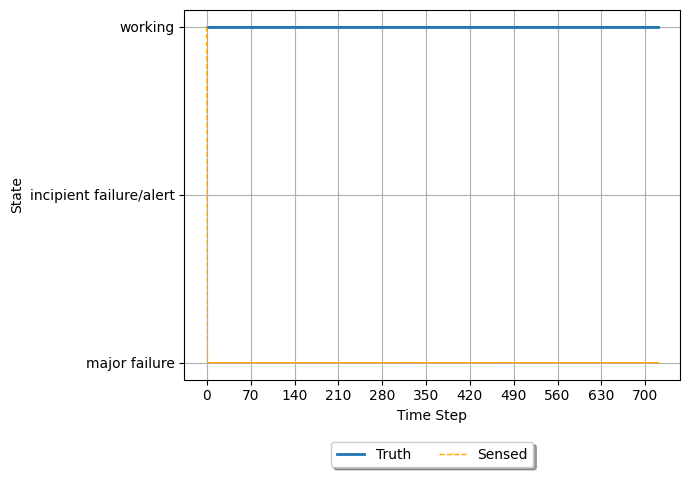

[2,
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 n

In [5]:
#  unpickle the data of one of the ships
file_path = "./simulatedShipData/simParam_(7, 'bad')/simNum_4.pkl" # bad sensing ship
# file_path = "./simulatedShipData/simParam_(3, 'good')/simNum_0.pkl" # good sensing ship

with open(file_path, 'rb') as file:
    sensed_ship = pickle.load(file)
sensed_ship.plotHistory()
# len(sensed_ship.ship.history)
sensed_ship.sensedHistory

# print the sensor observation matrix for each sensor on the first component of the engine #1 system
# sys_1_sensed_comps = sensed_ship.sensedSystems[1].sensedComps
# sys_1_sensed_comps[0].comp.name
# for sensor in sys_1_sensed_comps[0].sensors:
#     print(sensor.observation_probs)

In [6]:


# NOTE: can run all simulation parameter for 10 simulations in about 2 minutes (without plotting) or in about 8 minutes (with plotting)

# specify (sensor number and quality) for each simulation
# specify (sensor number and quality) for each simulation
# simulation_parameters =[ (1, 'bad'),         # 1 bad quality sensor per component
#                          (1, 'moderate'),   # 1 moderate quality sensor per component
#                          (1, 'good')]       # 1 good quality sensor per component

simulation_parameters =[ (1, 'bad'),         # 1 bad quality sensor per component
                         (1, 'moderate'),   # 1 moderate quality sensor per component
                         (1, 'good'),       # 1 good quality sensor per component
                         (3, 'bad'),        # 3 bad quality sensors per component
                         (3, 'moderate'),   # 3 moderate quality sensors per component
                         (3, 'good'),       # 3 good quality sensors per component
                         (7, 'bad'),        # 7 bad quality sensors per component
                         (7, 'moderate'),   # 7 moderate quality sensors per component
                         (7, 'good')]       # 7 good quality sensors per component

num_simulations = 1000   # number of times to run each simulation parameter

# set up lists for storing relevant data
count_false_alarms = np.zeros((len(simulation_parameters), num_simulations)) # percent of total incipent failures that were actually working
count_unexpected_failures = np.zeros((len(simulation_parameters), num_simulations)) # percent of total failures that were unexpected (not predicted by sensors)


# initialize a repairable ship
repairable_aux_ship = Ship('RepairableShip', 
                          'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', 
                          repairable=True)

# run the simulations
for i in range(len(simulation_parameters)):
    print("simulation_parameters: Number of Sensors = ", simulation_parameters[i][0], ", Sensor Quality = ", simulation_parameters[i][1])
    
    for j in range(num_simulations):
        print(f"Simulation {j+1} of {num_simulations}")

        # attach sensors to the ship ( base case = 1 sensor, bad quality ) 
        sensors = [[simulation_parameters[i] for comps in system.comps] for system in repairable_aux_ship.systems.values()]  # number of sensors per component, sensor quality
        sensed_R_aux_ship = SensedShip(repairable_aux_ship)
        sensed_R_aux_ship.attach_sensors()                    # attach sensors to each system

        sensed_R_aux_ship.simulate(720)  # simulate for 720 hours (30 days)
        # sensed_R_aux_ship.plotHistory()

        # save the state of the ship after simulation
        file_path = f"./simulatedShipData/simParam_{i}/simNum_{j}.pkl"
        with open(file_path, 'wb') as file:
            pickle.dump(sensed_R_aux_ship, file)
        
        # calculate relevant data
        count_false_alarms[i][j] = sensed_R_aux_ship.getFalseAlarmRate()
        count_unexpected_failures[i][j] = sensed_R_aux_ship.getUnexpectedFailureRate()

        # reset the ship for the next simulation
        sensed_R_aux_ship.reset()

# print out results
headers = ["Simulation Parameters", "False Alarm (%)", "Unexpected Failure (%)"]
rows = []
for i in range(len(simulation_parameters)):
    rows.append([simulation_parameters[i], count_false_alarms[i].mean(), count_unexpected_failures[i].mean()]) # averages for each simulation parameter

print(create_multi_simulation_table(headers, rows))

FileNotFoundError: [Errno 2] No such file or directory: 'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx'

Simulate n non-repairable auxillary ships

In [ ]:
from utils.RAM_Functions import calculate_availability
from utils.RAM_Functions import calculate_sensor_reliability

numpy.random.seed(12)  # for reproducibility

num_simulations = 100   # number of times to run the non-repairable ship simulation

# initialize a non-repairable ship
no_repair_aux_ship = Ship('noRepairShip', 'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', repairable=False)
sensed_NR_aux_ship = SensedShip(no_repair_aux_ship)
sensed_NR_aux_ship.attach_sensors()  # attach sensors to each system

failure_times = []  # failure time for each simulation
availability = []   # availability for each simulation
ship_histories = {} # store the truth and sensed histories for each simulation

# run n simulations and record relevant data
for i in range(num_simulations):

    # print iteration number
    print(i+1)

    # simulate until ship fails
    while(sensed_NR_aux_ship.ship.state > 0):  # simulate until ship fails
        sensed_NR_aux_ship.simulate(1)

        if len(sensed_NR_aux_ship.ship.history) > 350000:  # prevent infinite loop, assume max operation time = 350,000 hours
            print("Ship did not fail within 350,000 hours, stopping simulation")
            break

    # determine when the ship failed (or when simulation stopped) and to list for reliability curve plotting
    failure_times.append(len(sensed_NR_aux_ship.ship.history))
    
    # store ship history for this simulation
    ship_histories[f'Simulation_{i+1}'] = (sensed_NR_aux_ship.ship.history, sensed_NR_aux_ship.sensedHistory)

    # optional: plot the ship's state history
    # sensed_NR_aux_ship.plotHistory()

    # reset ship for next simulation
    sensed_NR_aux_ship.reset()

NameError: name 'numpy' is not defined

Calculate Reliability for the simulated ships

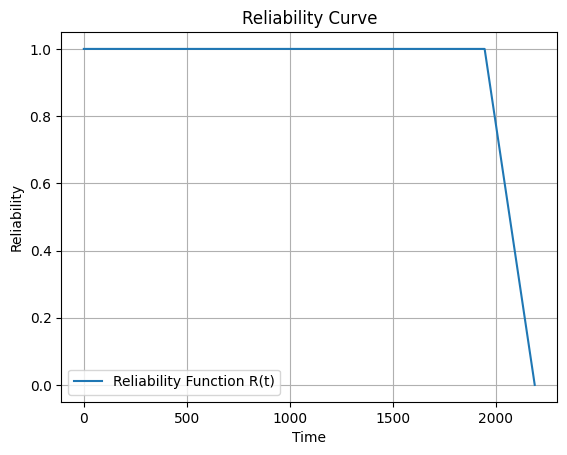

Reliability at 720 Hours: 100.00%
Average Availability: 69.68%
Min Failure Time: 2190 hours
Max Failure Time: 2190 hours
Mean Failure Time: 2190.00 hours
Median Failure Time: 2190 hours
Mode Failure Time: 2190 hours


In [ ]:
from utils.RAM_Functions import drawRelCurve
from utils.helperFunctions import find_mode

# Draw Reliability Curve
drawRelCurve(failure_times)

# Calculate Reliability at 720 Hours
reliability_at_720 = sum(1 for time in failure_times if time >= 720) / num_simulations
print(f"Reliability at 720 Hours: {reliability_at_720*100:.2f}%")

# print average availability
average_availability = sum(availability) / num_simulations
print(f"Average Availability: {average_availability*100:.2f}%")

# Calculate relevant failure statistics
min_failure_times = min(failure_times)
max_failure_times = max(failure_times)
mean_failure_time = sum(failure_times) / num_simulations
median_failure_time = sorted(failure_times)[num_simulations // 2]
mode_failure_time = find_mode(failure_times)
print(f"Min Failure Time: {min_failure_times} hours")
print(f"Max Failure Time: {max_failure_times} hours")
print(f"Mean Failure Time: {mean_failure_time:.2f} hours")
print(f"Median Failure Time: {median_failure_time} hours")
print(f"Mode Failure Time: {mode_failure_time} hours")


simulate n repairable ships for three months (2190 hours)

In [ ]:
from utils.RAM_Functions import calculate_availability
from utils.RAM_Functions import calculate_sensor_reliability

numpy.random.seed(12)  # for reproducibility

num_simulations = 100   # number of times to run the non-repairable ship simulation

# initialize a non-repairable ship
no_repair_aux_ship = Ship('noRepairShip', 'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', repairable=False)
sensed_NR_aux_ship = SensedShip(no_repair_aux_ship)
sensed_NR_aux_ship.attach_sensors()  # attach sensors to each system

failure_times = []  # failure time for each simulation
availability = []   # availability for each simulation
ship_histories = {} # store the truth and sensed histories for each simulation

# run n simulations and record relevant data
for i in range(num_simulations):

    # print iteration number
    print(i+1)

    # simulate for three months (2190 hours)
    sensed_NR_aux_ship.simulate(2190)  

    # determine the ships availability for this simulation
    availability.append(calculate_availability(sensed_NR_aux_ship.ship.history))

    # store ship history for this simulation
    ship_histories[f'Simulation_{i+1}'] = (sensed_NR_aux_ship.ship.history, sensed_NR_aux_ship.sensedHistory)

    # optional: plot the ship's state history
    # sensed_NR_aux_ship.plotHistory()

    # reset ship for next simulation
    sensed_NR_aux_ship.reset()


truth_histories = [v[0] for v in ship_histories.values()]
sensed_histories = [v[1] for v in ship_histories.values()]

sensor_reliability_table = calculate_sensor_reliability(truth_histories, sensed_histories)
print(sensor_reliability_table)

Calculate sensor reliability numbers for an additional simulation